# NORMALISASI Z-SCORE #

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# DATA
# ==============================================================================
df_zscore = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_zscore[kolom_string] = df_zscore[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_zscore.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_zscore

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [20]:
# ==============================================================================
# STANDARDISASI Z-SCORE
# ==============================================================================
scaler = StandardScaler()

df_zscore[kolom_numerik] = scaler.fit_transform(df_zscore[kolom_numerik])

print("========== HASIL STANDARDISASI Z-SCORE ==========")
df_zscore

========== HASIL STANDARDISASI Z-SCORE ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675


* K-MEANS CLUSTERING


In [21]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [22]:
#===============================================================================
# DATA
#===============================================================================

df_zscore_kmeans = df_zscore.copy()
df_zscore_kmeans

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675


========== ELBOW METHOD ==========


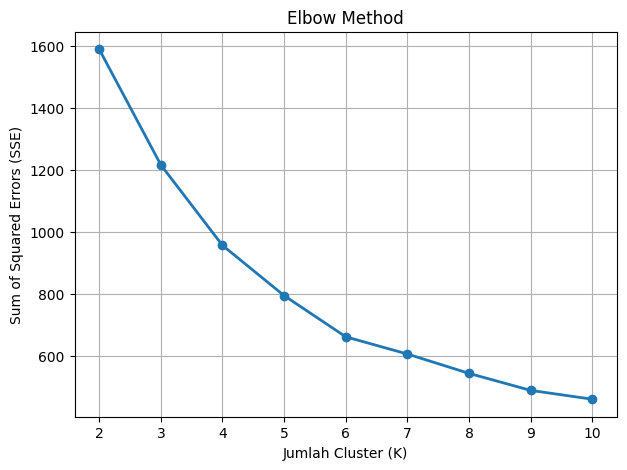

In [23]:
#===============================================================================
# 1. TENTUKAN JUMLAH CLUSTER (K)
#===============================================================================

# --------------------------
# 1.1. ELBOW METHOD
# --------------------------

print("========== ELBOW METHOD ==========")

sse = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(df_zscore_kmeans[kolom_numerik])
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(7,5))
plt.plot(
    K,
    sse,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.xticks(K)
plt.grid(True)

plt.show()

In [24]:
# --------------------------
# 1.2. SILHOUETTE SCORE, DAVIES-BOULDIN INDEX, CALINSKI-HARABASZ INDEX
# --------------------------

hasil_evaluasi = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    cluster = kmeans.fit_predict(df_zscore_kmeans[kolom_numerik])

    silhouette = silhouette_score(df_zscore_kmeans[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_zscore_kmeans[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_zscore_kmeans[kolom_numerik], cluster)

    hasil_evaluasi.append({
        'Jumlah Cluster (K)': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

hasil_evaluasi = pd.DataFrame(hasil_evaluasi)

print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.3686,1.4354,89.3474
1,3,0.2425,1.2234,98.5019
2,4,0.2777,1.0532,106.8932
3,5,0.2749,1.0942,109.4602
4,6,0.3124,1.0391,115.2119
5,7,0.3120,1.1255,108.3527
6,8,0.2699,1.1925,107.3924
7,9,0.2970,1.0945,107.7188
8,10,0.2868,1.1922,103.0336


In [25]:
# --------------------------
# 1.3. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 2


In [26]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 6


In [27]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 6


_KLASTER OPTIMAL YANG DIGUNAKAN_

In [28]:
k = 6

In [29]:
#===============================================================================
# 2. PROSES K-MEANS CLUSTERING
#===============================================================================

# --------------------------
# 2.1. INISIALISASI MODEL & PARAMETER K-MEANS
# --------------------------
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42
)

# --------------------------
# 2.2. FIT MODEL K-MEANS
# --------------------------
kmeans.fit(df_zscore_kmeans[kolom_numerik])


#--------------------------
# 2.3. SIMPAN CENTROID
#--------------------------
centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=kolom_numerik
)

centroid.insert(0, "Cluster", range(1, len(centroid) + 1))

print("========== CENTROID ==========")
display(centroid)



========== CENTROID ==========


,Cluster,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,1,-0.627905,1.811861,1.105079,0.089182,0.633280,0.912687,0.286816,1.378510
1,2,-0.436289,-1.387812,-0.969678,-0.237857,-0.471761,-0.704974,-0.293152,-1.235586
2,3,-0.405880,0.381337,-0.158774,-0.212929,-0.321768,-0.120262,-0.145189,-0.157430
3,4,3.296153,0.615104,3.149809,9.871105,6.239343,1.307285,9.338377,2.851596
4,5,3.275212,0.635569,1.365491,0.740780,4.631069,3.671866,0.431631,2.841711
5,6,1.100955,-0.305821,0.565219,0.229445,0.251747,0.184663,0.106046,0.584205


In [30]:
# ---------------------------
# 2.4. SIMPAN LABEL CLUSTER
# ---------------------------

print("========== LABEL CLUSTER ==========")
df_zscore_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_zscore[kolom_numerik])
df_zscore_kmeans["cluster_kmeans"] = kmeans.labels_ + 1
df_zscore_kmeans

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864,3
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574,3
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987,3
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162,3
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618,2
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705,2
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270,2
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675,5


In [31]:
#===============================================================================
# 2.5. SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI)
#===============================================================================
df_hasil = pd.read_csv('dataset_baru.csv').copy()

df_hasil["cluster_kmeans"] = kmeans.labels_ + 1

print("========== HASIL CLUSTERING K-MEANS ==========")
display(df_hasil)

========== HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,PACITAN,2018,9,15,347,141,619,41173,292,592938,3
1,35,JAWA TIMUR,3502,PONOROGO,2018,12,19,519,129,990,46778,479,962125,3
2,35,JAWA TIMUR,3503,TRENGGALEK,2018,3,19,384,227,792,40464,285,748432,3
3,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,3
4,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469,2
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272,2
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733,2
264,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,5


In [32]:
# ---------------------------
# JUMLAH ANGGOTA CLUSTER
# ---------------------------

jumlah_cluster = (
    df_hasil["cluster_kmeans"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_kmeans
1     23
2     54
3    123
4      2
5      5
6     59
Name: count, dtype: int64

In [33]:
#===============================================================================
# 3. EVALUASI HASIL CLUSTERING K-MEANS
#===============================================================================

silhouette = silhouette_score(
    df_zscore_kmeans[kolom_numerik],
    df_zscore_kmeans['cluster_kmeans']
)

dbi = davies_bouldin_score(
    df_zscore_kmeans[kolom_numerik],
    df_zscore_kmeans['cluster_kmeans']
)

chi = calinski_harabasz_score(
    df_zscore_kmeans[kolom_numerik],
    df_zscore_kmeans['cluster_kmeans']
)

print("========== HASIL EVALUASI K-MEANS ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI K-MEANS ==========
Silhouette Score        : 0.3124
Davies-Bouldin Index    : 1.0391
Calinski-Harabasz Index : 115.2119


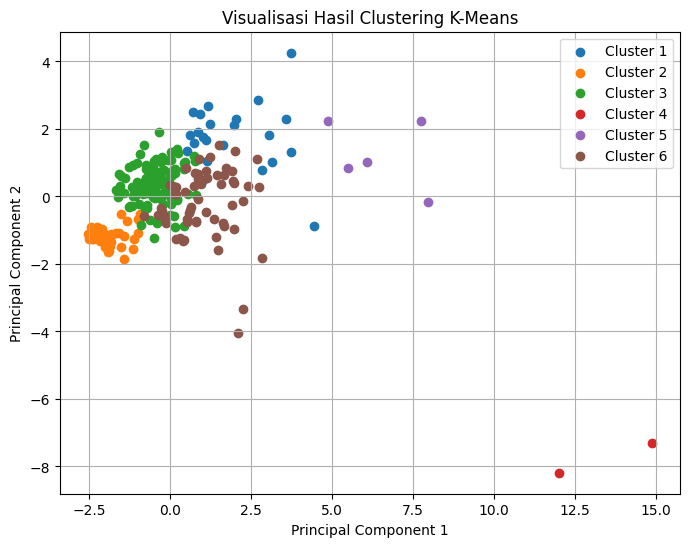

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore_kmeans[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["Cluster"] = kmeans.labels_ + 1

plt.figure(figsize=(8,6))

for cluster in sorted(df_pca["Cluster"].unique()):
    subset = df_pca[df_pca["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}"
    )

plt.title("Visualisasi Hasil Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()